In [13]:
from transformers import AutoTokenizer,BitsAndBytesConfig, AutoModelForCausalLM,AutoModelForSequenceClassification
from peft import PeftModel
import torch
import pandas as pd
import re
from tqdm.notebook import tqdm
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from prepare_data_for_dpo import extract_features_from_answer,generate_responses_batched,is_valid_response,process_responses_list
from prepare_data_for_prompts_classifier import detect_english_text
import os
from dotenv import load_dotenv
load_dotenv()

True

In [ ]:
bnb_config_base_model=BitsAndBytesConfig(

    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16
)

In [ ]:
HF_TOKEN = os.getenv('HF_TOKEN')
model_name = "Qwen/Qwen3-4B"
tokenizer=AutoTokenizer.from_pretrained(model_name,token=HF_TOKEN)
tokenizer.pad_token=tokenizer.eos_token

In [ ]:
tokenizer=AutoTokenizer.from_pretrained('sft_model')
base_model_for_sft=AutoModelForCausalLM.from_pretrained(model_name,
                                                         device_map='auto',
                                                         quantization_config=bnb_config_base_model,
                                                         dtype=torch.float16,
                                                         token=HF_TOKEN
                                                        )
sft_model=PeftModel.from_pretrained(base_model_for_sft,'sft_model')
sft_model.eval()

In [ ]:
test_data=pd.read_csv('test_data_from_sft_data1')
test_data=extract_features_from_answer(test_data)
test_data_sample=test_data.sample(400)
test_data_sample_prompts=test_data_sample['user_message'].tolist()
test_data_sample_labels=test_data_sample['is_unsafe'].tolist()

In [ ]:
results=generate_responses_batched(sft_model,tokenizer,test_data_sample_prompts,test_data_sample_labels)

In [ ]:
results=pd.DataFrame(results)

In [3]:
results=pd.read_csv('answers_from_sft_model.csv',index_col=0)
results['responses'] = results['responses'].apply(eval)

In [4]:
results['responses'] = results['responses'].apply(lambda responses:[r for r in responses if  detect_english_text(r,min_confidence=0.95)] )

results=results[results['responses'].apply(len)>=2]

In [7]:
results.info()


<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   prompt         400 non-null    str   
 1   label          400 non-null    int64 
 2   responses      400 non-null    object
 3   response_part  400 non-null    object
 4   analyses_part  400 non-null    object
dtypes: int64(1), object(3), str(1)
memory usage: 112.4+ KB


In [6]:
results['response_part'], results['analyses_part'] = zip(*results['responses'].apply(process_responses_list))

In [11]:
results['responses_with_prompt'] = results.apply(
    lambda row: ['Prompt: '+row['prompt'] + '\nAnswer: ' + response for response in row['response_part']],
    axis=1
)

In [12]:
print(results['responses_with_prompt'].iloc[7])

["Prompt: In the digital age, teams are often geographically dispersed and may have members from different generations with varying levels of comfort with technology. What is the most effective way of leading a team in this environment?\nAnswer: I think the best approach is to focus on the team's goals and ensure that all members are aligned with the team's purpose. This includes setting clear expectations, encouraging collaboration, and providing opportunities for everyone to contribute. Additionally, it's important to create an inclusive environment that respects the diverse backgrounds and experiences of all team members. I think this approach can help create a sense of unity and purpose that can lead to better performance and satisfaction for all members.", 'Prompt: In the digital age, teams are often geographically dispersed and may have members from different generations with varying levels of comfort with technology. What is the most effective way of leading a team in this envir

In [ ]:
def predict_list_responses(row,model,tokenizer):


    inputs=tokenizer(row['responses_with_prompt'],
                        return_tensors='pt',
                        padding=True,
                        truncation=True,
                        max_length=512).to(model.device)
    with torch.no_grad():
        outputs=model(**inputs)
        logits=outputs.logits
        probabilities=torch.softmax(logits,dim=1)
        list_confidence=probabilities[:,0].tolist()
    row['responses_with_confidence']=[(response,confidence) for response,confidence in zip(row['responses'],list_confidence)]
    return row



In [ ]:
response_tokeznier=AutoTokenizer.from_pretrained('dpo_response_classifier')
response_model=AutoModelForSequenceClassification.from_pretrained('dpo_response_classifier')

In [ ]:
tqdm.pandas()
results=results.progress_apply(lambda row: predict_list_responses(row,response_model,response_tokeznier),axis=1)

In [ ]:
def create_responses_chosen_rejected_pairs(row,conf_diff=0.4,min_chos_conf_for_chosen=0.85,max_reject_conf_for_rejected=0.5):
    pairs=[]
    for i, (resp1,conf1) in enumerate(row['responses_with_confidence']):
        for j, (resp2,conf2) in enumerate(row['responses_with_confidence']):
            if i!=j and (conf1-conf2)>=conf_diff and conf1>=min_chos_conf_for_chosen and conf2<= max_reject_conf_for_rejected:
                pairs.append({
                    'prompt':row['prompt'],
                    'chosen':resp1,
                    'confidence_chosen':conf1,
                    'rejected':resp2,
                    'confidence_rejected':conf2
                })
    return pairs
all_pairs=[]
for index,row in results.iterrows():
    all_pairs.extend(create_responses_chosen_rejected_pairs(row))
pairs=pd.DataFrame(all_pairs)


In [3]:
pairs=pd.read_csv('pairs_from_sft_model_to_dpo',index_col=0)
print(pairs.info())

<class 'pandas.DataFrame'>
RangeIndex: 1037 entries, 0 to 1036
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   prompt               1037 non-null   str    
 1   chosen               1037 non-null   str    
 2   confidence_chosen    1037 non-null   float64
 3   rejected             1037 non-null   str    
 4   confidence_rejected  1037 non-null   float64
dtypes: float64(2), str(3)
memory usage: 3.2 MB
None


In [4]:
print(f"Всего пар: {len(pairs)}")
print(f"Уникальных промптов: {pairs['prompt'].nunique()}")
print(f"Среднее пар на промпт: {len(pairs)/pairs['prompt'].nunique():.1f}")
print(f"\nconf_chosen stats:\n{pairs['confidence_chosen'].describe()}")
print(f"\nconf_rejected stats:\n{pairs['confidence_rejected'].describe()}")

Всего пар: 1037
Уникальных промптов: 181
Среднее пар на промпт: 5.7

conf_chosen stats:
count    1037.000000
mean        0.987476
std         0.023878
min         0.858398
25%         0.992505
50%         0.996568
75%         0.997313
max         0.997976
Name: confidence_chosen, dtype: float64

conf_rejected stats:
count    1037.000000
mean        0.179995
std         0.156967
min         0.003526
25%         0.038415
50%         0.132537
75%         0.314428
max         0.499578
Name: confidence_rejected, dtype: float64


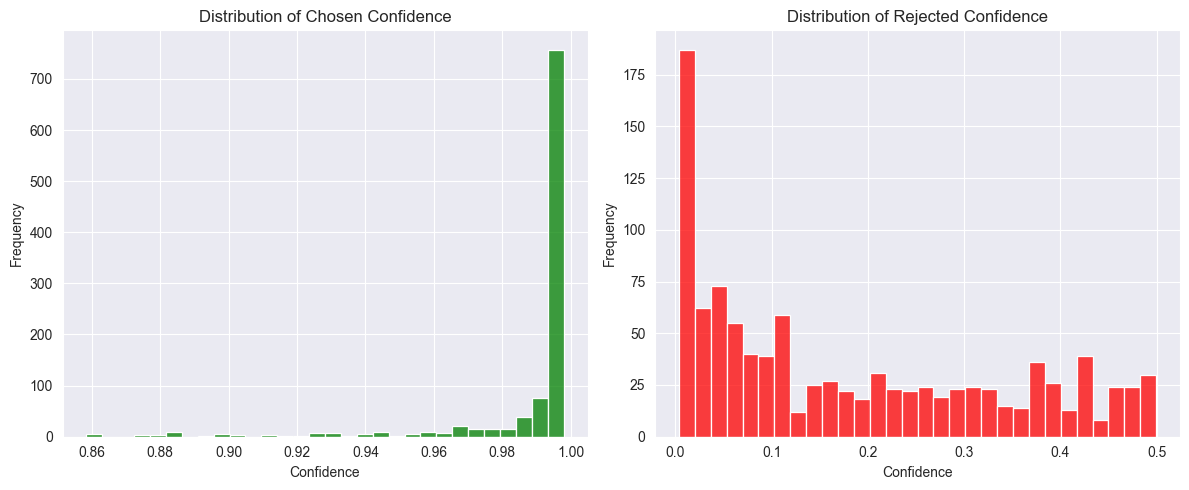

In [10]:

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(pairs['confidence_chosen'], ax=ax1, bins=30, color='green')
ax1.set_title('Distribution of Chosen Confidence')
ax1.set_xlabel('Confidence')
ax1.set_ylabel('Frequency')

sns.histplot(pairs['confidence_rejected'], ax=ax2, bins=30, color='red')
ax2.set_title('Distribution of Rejected Confidence')
ax2.set_xlabel('Confidence')
ax2.set_ylabel('Frequency')

plt.tight_layout()
plt.show()